# Problem Set 4: Kernel Density Estimation



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statistics import NormalDist


## Problem 1


### Handwritten work for Problem 1

<img src="IMG_9399.jpeg" alt="Problem 1 handwritten work" width="600">

## Problem 2

2a. The estimate is **0.50**.

2b. The expected estimate is **0.38**.

2c. The true density is **0.40**.

2d. They are different, so this suggests some bias at this bandwidth.

2e. At h = 0.10, the expected estimate is **0.40**, closer to the true value.

2f. Yes. The estimate becomes consistent when h shrinks as the sample grows, while n times h grows.

2g. Choose h to balance a smooth curve against following the data closely.


In [2]:
X = np.array([-1.0, -0.5, 0.0, 0.5, 1.0])
normal = NormalDist()

# 2a
h = 0.6
x0 = 0.0
f_hat_2a = 0.5

# 2b
E_2b = (normal.cdf(x0 + h) - normal.cdf(x0 - h)) / (2 * h)

# 2c
f_true_2c = normal.pdf(x0)

# 2e
h_small = 0.1
E_2e = (normal.cdf(x0 + h_small) - normal.cdf(x0 - h_small)) / (2 * h_small)

## Problem 3

In [3]:
X3 = np.array([5.0, 7.0, 7.0, 8.0, 10.0])
h = 1.5
points = np.array([6.0, 6.5, 7.0, 8.0, 8.5])

# 3a
uniform_vals = []
for x in points:
    c = np.sum(np.abs(X3 - x) <= h)
    uniform_vals.append(c / (len(X3) * 2 * h))

# 3b
gaussian_vals = []
for x in points:
    z = (X3 - x) / h
    g = np.mean(np.exp(-0.5 * z**2) / (h * np.sqrt(2 * np.pi)))
    gaussian_vals.append(g)

# 3c
jump = max(np.abs(np.diff(uniform_vals)))

3a. Uniform KDE values: **0.20, 0.27, 0.27, 0.20, 0.27**.

3b. Gaussian KDE values: **0.15, 0.17, 0.18, 0.17, 0.15**.

3c. The largest jump is **0.07**. It is tied between x = 6.00 to 6.50, x = 7.00 to 8.00, and x = 8.00 to 8.50. A uniform kernel has sharp edges, so points suddenly enter or leave its window. A Gaussian kernel has no sharp edge, so each point's effect changes gradually.

3d. I prefer the Gaussian kernel because its curve changes smoothly.


## Problem 4
4a. Plot the KDE for `ejection_fraction`.

4b. Plot KDEs from 15 samples drawn with replacement.

4c. The estimate is most reliable from about 25 to 65, where the curves mostly overlap. The curves vary more below 25 and above 65, near the ends of the data.

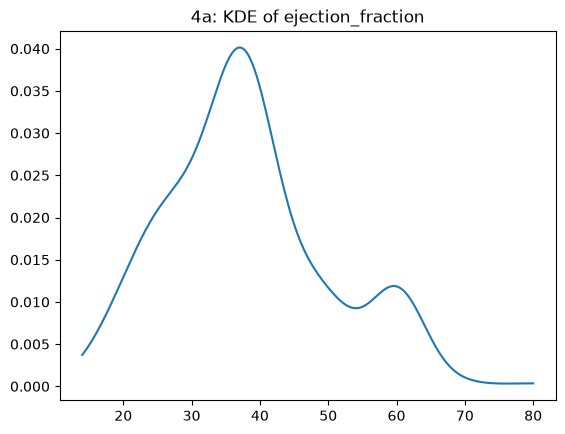

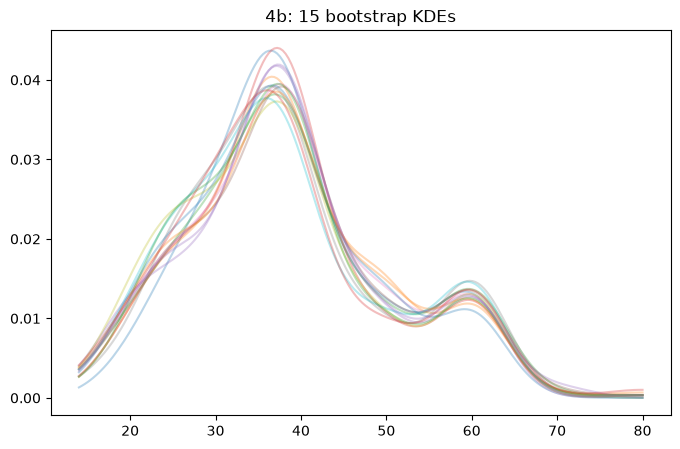

In [4]:
df = pd.read_csv('../data/heart_failure_clinical_records_dataset.csv')
x = df['ejection_fraction']
k = 1.06 * x.std(ddof=1) * len(x) ** (-0.2)
xs = np.linspace(x.min(), x.max(), 200)

# 4a
vals = []
for xi in xs:
    g = np.mean(np.exp(-0.5 * ((x - xi) / k) ** 2) / (k * np.sqrt(2 * np.pi)))
    vals.append(g)
plt.plot(xs, vals)
plt.title('4a: KDE of ejection_fraction')
plt.show()

# 4b
plt.figure(figsize=(8, 5))
for i in range(15):
    sample = df.sample(frac=1.0, replace=True, random_state=i)['ejection_fraction']
    vals_sample = []
    for xi in xs:
        g = np.mean(np.exp(-0.5 * ((sample - xi) / k) ** 2) / (k * np.sqrt(2 * np.pi)))
        vals_sample.append(g)
    plt.plot(xs, vals_sample, alpha=0.3)
plt.title('4b: 15 bootstrap KDEs')
plt.show()
